In [1]:
import pandas as pd 
import numpy as np  
import os

In [3]:
train_csv = pd.read_csv("Data/train.csv")

In [22]:
train_csv.head(10)

,our_id,cavity,age_of_onset,gender,type_of_resistance,comorbidity,outcome,imaging_date,series_modality_cd
0,2,large,57,Male,XDR,Not specified,Cured,38,CR
1,4,large,52,Male,MDR non XDR,Others,Cured,93,XC
2,5,large,57,Female,MDR non XDR,"Diabetes, Hepatitis C, Others",Cured,2,CR
3,6,large,31,Female,XDR,Others,Died,98,CR
4,8,large,69,Male,MDR non XDR,NaN,Died,-7,XC
5,9,large,53,Male,MDR non XDR,Others,Died,-6,CR
6,13,large,39,Female,MDR non XDR,Others,Failure,36,CR
7,14,large,33,Male,MDR non XDR,Not specified,Cured,-2,XC
8,15,large,44,Male,Pre-XDR,Others,Died,-1,CR
9,16,large,35,Female,MDR non XDR,Others,Lost to follow up,95,CR


In [5]:
print(train_csv.shape)
for column in train_csv.columns:
    train_csv[column].value_counts()

(444, 9)


In [6]:
cavity_pos = train_csv.shape[0] - ((train_csv['cavity'] == 'none').sum())
print(f"Number of cavity positive: {cavity_pos}")

Number of cavity positive: 197


In [ ]:
"""
일단 여기서 preprocessing ㅣ진행하고
모겔에 주입하기 전에 자르고 ㅣ븅ㄹ로
그리고 인터헌스?
"""

In [8]:
train_csv['gender'].value_counts()

gender
Male      317
Female    127
Name: count, dtype: int64

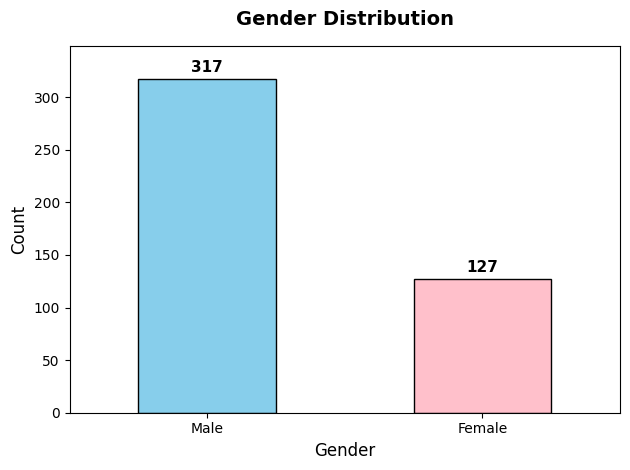

In [19]:
import matplotlib.pyplot as plt

gender_counts = train_csv['gender'].value_counts()
ax = gender_counts.plot(kind='bar', color=['skyblue', 'pink'], edgecolor='black')
ax.bar_label(ax.containers[0], padding=3, fontsize=11, fontweight='bold')

plt.title('Gender Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)

# 5. Dynamically pad the top of the y-axis so the labels don't get cut off
plt.ylim(0, max(gender_counts.values) * 1.1)
plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=300)

In [20]:
train_csv['cavity'].value_counts()

cavity
none      247
small      79
medium     61
large      57
Name: count, dtype: int64

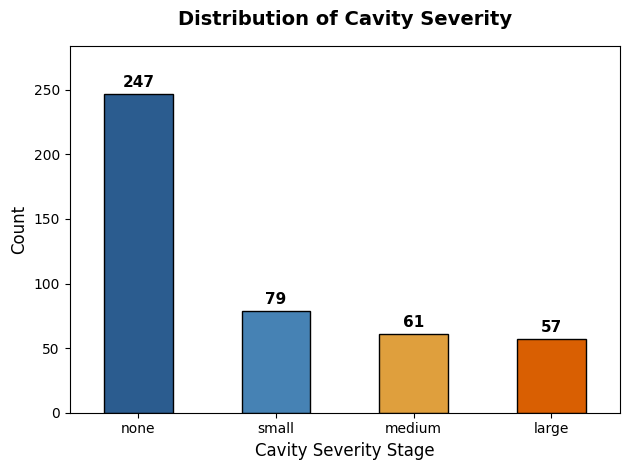

In [21]:
import matplotlib.pyplot as plt

# 1. Compute the counts for the 4 cavity values
cavity_counts = train_csv['cavity'].value_counts()

# 2. Plot as a bar chart with 4 distinct colors
# (Using a sleek, professional palette: teal, sage, amber, and coral)
colors = ['#2b5c8f', '#4682b4', '#df9f3d', '#d95f02']
ax = cavity_counts.plot(kind='bar', color=colors, edgecolor='black')

# 3. Write the counts directly on top of each bar
ax.bar_label(ax.containers[0], padding=3, fontsize=11, fontweight='bold')

# 4. Add titles and labels
plt.title('Distribution of Cavity Severity', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cavity Severity Stage', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)  # Keeps the x-axis labels level and readable

# 5. Add 15% headroom above the tallest bar so the number fits comfortably
plt.ylim(0, max(cavity_counts.values) * 1.15)

# 6. Save or display the plot
plt.tight_layout()
plt.savefig('cavity_distribution.png', dpi=300)

In [23]:
train_csv['type_of_resistance'].value_counts()

type_of_resistance
MDR non XDR    198
Sensitive      121
XDR             80
Mono DR         23
Pre-XDR         16
Poly DR          6
Name: count, dtype: int64

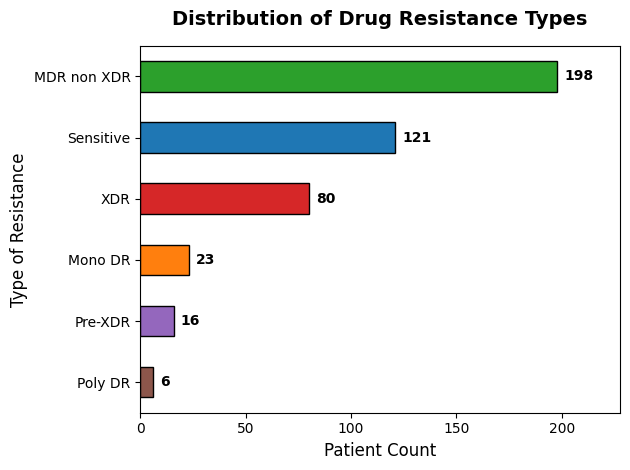

In [25]:
resistance_counts = train_csv['type_of_resistance'].value_counts()
colors = ['#2ca02c', '#1f77b4', '#d62728', '#ff7f0e', '#9467bd', '#8c564b']
ax = resistance_counts.plot(kind='barh', color=colors, edgecolor='black')

# 3. Write numbers directly on the bars (using the x-coordinate instead of y)
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold')

# 4. Styling
plt.title('Distribution of Drug Resistance Types', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Patient Count', fontsize=12)
plt.ylabel('Type of Resistance', fontsize=12)

# 5. Add 15% headroom on the x-axis so labels don't get cut off
plt.xlim(0, max(resistance_counts.values) * 1.15)

# Invert y-axis to keep the highest count (MDR) on top
plt.gca().invert_yaxis()  

plt.tight_layout()
plt.savefig('resistance_distribution.png', dpi=300)

In [36]:
clean_ages = pd.to_numeric(train_csv['age_of_onset'], errors='coerce').dropna()

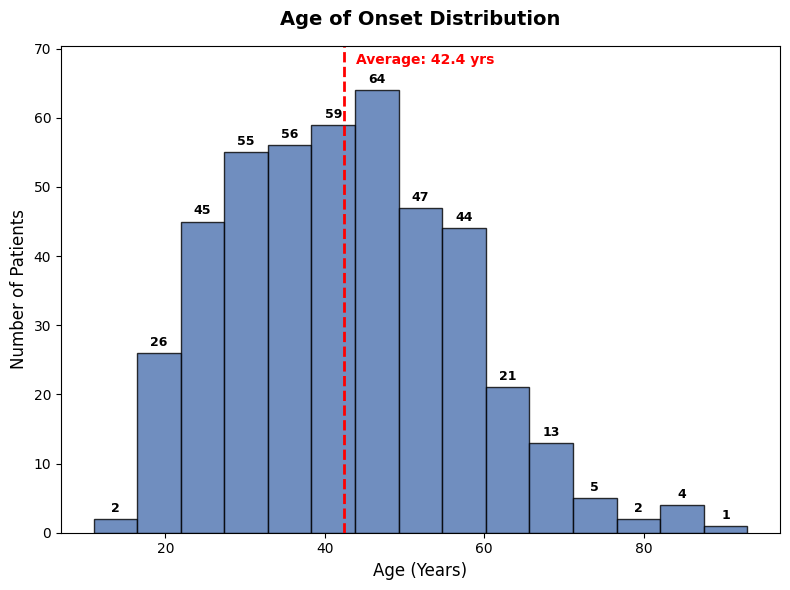

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clean the data (Handle NaNs and Text types)
clean_ages = pd.to_numeric(train_csv['age_of_onset'], errors='coerce').dropna()

# 2. Initialize the Figure and Axes
fig, ax = plt.subplots(figsize=(8, 6))

# 3. Plot the histogram using clean data
counts, bins, patches = ax.hist(clean_ages, bins=15, color='#4C72B0', edgecolor='black', alpha=0.8)

# 4. Write the bin counts directly on top of each histogram bar
ax.bar_label(patches, padding=3, fontsize=9, fontweight='bold')

# 5. Add a vertical line for the Mean (Average) Age using clean data
mean_age = clean_ages.mean()
ax.axvline(mean_age, color='red', linestyle='--', linewidth=2)

# Write the average value text directly next to the vertical line
ax.text(mean_age + 1.5, max(counts) * 1.06, f'Average: {mean_age:.1f} yrs', color='red', fontweight='bold', fontsize=10)

# 6. Add Titles & Labels
plt.title('Age of Onset Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Give 10% headroom at the top of the y-axis for labels
plt.ylim(0, max(counts) * 1.1)

# 7. Save or display the plot
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=300)

In [48]:
train_csv['comorbidity'].value_counts()

comorbidity
Others                                     136
Not specified                               52
Diabetes                                    18
HIV                                         16
Diabetes, Others                             9
COVID-19, Others                             6
Hepatitis C, HIV, Others                     5
HIV, Others                                  5
COVID-19                                     5
Hepatitis C                                  5
Psychiatric illness                          4
Anemia, HIV                                  3
Hepatitis C, HIV                             3
Anemia                                       3
Post-COVID-19                                2
Diabetes, Hepatitis C, Others                2
COVID-19, Diabetes                           1
COVID-19, Hepatitis C                        1
COVID-19, Psychiatric illness                1
Anemia, COVID-19, Others                     1
Hepatic diseases                             1
A

In [50]:
train_csv['outcome'].value_counts()

outcome
Cured                 283
Completed              52
Lost to follow up      33
Died                   33
Failure                32
Still on treatment      6
Unknown                 4
Palliative Care         1
Name: count, dtype: int64

In [52]:
df = train_csv.drop(columns=['

,our_id,cavity,age_of_onset,gender,type_of_resistance,comorbidity,outcome,imaging_date,series_modality_cd
0,2,large,57,Male,XDR,Not specified,Cured,38,CR
1,4,large,52,Male,MDR non XDR,Others,Cured,93,XC
2,5,large,57,Female,MDR non XDR,"Diabetes, Hepatitis C, Others",Cured,2,CR
3,6,large,31,Female,XDR,Others,Died,98,CR
4,8,large,69,Male,MDR non XDR,NaN,Died,-7,XC
...,...,...,...,...,...,...,...,...,...
439,593,none,54,Male,MDR non XDR,Not specified,Failure,1774,CR
440,595,none,35,Female,MDR non XDR,NaN,Completed,90,CR
441,598,none,26,Male,Sensitive,NaN,Cured,4,CR
442,599,none,56,Male,Mono DR,NaN,Cured,-9,XC
